In [ ]:
import gym
import matplotlib.pyplot as plt


In [ ]:
env=gym.make('FrozenLake-v1', map_name='8x8' , render_mode="ansi")
env.reset()
print(env.render())

['\n\x1bS\x1bFFFFFFF\nFFFFFFFF\nFFFHFFFF\nFFFFFHFF\nFFFHFFFF\nFHHFFFHF\nFHFFHFHF\nFFFHFFFG\n']


/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
print('Action Space: ' ,env.action_space)

Action Space:  Discrete(4)


In [ ]:
print('Observation Space: ', env.observation_space)

Observation Space:  Discrete(64)


In [ ]:
import numpy as np
MAX_ITERATIONS=10
env.reset()
for i in range(MAX_ITERATIONS):
    random_action = env.action_space.sample()
    new_state, reward, done, info = env.step(random_action)
    print("Action:", random_action)
    print("New state:", new_state)
    print("Reward:", reward)
    print("Done:", done)
    if done:
        print("Episode ended")
        break

Action: 1
New state: 1
Reward: 0.0
Done: False
Action: 0
New state: 0
Reward: 0.0
Done: False
Action: 1
New state: 8
Reward: 0.0
Done: False
Action: 0
New state: 0
Reward: 0.0
Done: False
Action: 0
New state: 8
Reward: 0.0
Done: False
Action: 2
New state: 16
Reward: 0.0
Done: False
Action: 2
New state: 17
Reward: 0.0
Done: False
Action: 1
New state: 16
Reward: 0.0
Done: False
Action: 0
New state: 16
Reward: 0.0
Done: False
Action: 3
New state: 16
Reward: 0.0
Done: False


In [ ]:
import numpy as np
import gymnasium as gym
actions={'Left':0, 'Down':1, 'Right':2, 'Up':3}
print("winning sequence :")
winning_sequence=(2*['Right'])+(3*['Down'])+(2*['Right'])+(4*['Down'])+(3*['Right'])
print(winning_sequence)
env=gym.make('FrozenLake-v1',map_name='8x8', render_mode='ansi')
env.reset()
print(env.render())
for a in winning_sequence:
  new_state,reward,terminated,truncated,info= env.step(actions[a])
  print("Action:", actions[a])
  print("New state:", new_state)
  print("Reward:", reward)
  if terminated or truncated:
    print("Episode Ended")
    break


winning sequence :
['Right', 'Right', 'Down', 'Down', 'Down', 'Right', 'Right', 'Down', 'Down', 'Down', 'Down', 'Right', 'Right', 'Right']

SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

Action: 2
New state: 8
Reward: 0
Action: 2
New state: 9
Reward: 0
Action: 1
New state: 8
Reward: 0
Action: 1
New state: 8
Reward: 0
Action: 1
New state: 9
Reward: 0
Action: 2
New state: 17
Reward: 0
Action: 2
New state: 25
Reward: 0
Action: 1
New state: 24
Reward: 0
Action: 1
New state: 24
Reward: 0
Action: 1
New state: 32
Reward: 0
Action: 1
New state: 33
Reward: 0
Action: 2
New state: 25
Reward: 0
Action: 2
New state: 26
Reward: 0
Action: 2
New state: 18
Reward: 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
P=env.unwrapped.P
print(P[15][2])

[(0.33333333333333337, 23, 0, False), (0.3333333333333333, 15, 0, False), (0.33333333333333337, 7, 0, False)]


In [ ]:
nS=env.observation_space.n
nA=env.action_space.n
print(nS)
print(nA)

64
4


In [ ]:
def value_iteration(p, nS, nA, gamma=0.99, theta=1e-9):
  V=np.zeros(nS)
  policy=np.zeros(nS,dtype=int)
  while True:
    delta=0.0
    for s in range(nS):
      q=np.zeros(nA)
      for a in range(nA):
        for prob, s_next , reward, done in P[s][a]:
          q[a]+=prob*(reward+gamma*V[s_next]*(not done))
      delta=max(delta,abs(q.max()-V[s]))
      V[s]=q.max()
      policy[s]=q.argmax()
    if delta < theta:
      break
  return policy,V
policy, V = value_iteration(P, nS, nA)
print("V:\n", V.reshape(8, 8).round(3))
print("policy:\n", policy.reshape(8, 8))

V:
 [[0.415 0.427 0.446 0.468 0.492 0.517 0.535 0.541]
 [0.412 0.421 0.437 0.458 0.483 0.514 0.546 0.557]
 [0.397 0.394 0.375 0.    0.422 0.494 0.561 0.586]
 [0.369 0.353 0.307 0.2   0.301 0.    0.569 0.628]
 [0.333 0.291 0.197 0.    0.289 0.362 0.535 0.69 ]
 [0.306 0.    0.    0.086 0.214 0.273 0.    0.772]
 [0.289 0.    0.058 0.048 0.    0.251 0.    0.878]
 [0.28  0.201 0.127 0.    0.24  0.486 0.737 0.   ]]
policy:
 [[3 2 2 2 2 2 2 2]
 [3 3 3 3 3 2 2 1]
 [3 3 0 0 2 3 2 1]
 [3 3 3 1 0 0 2 2]
 [0 3 0 0 2 1 3 2]
 [0 0 0 1 3 0 0 2]
 [0 0 2 0 0 0 0 2]
 [0 1 0 0 1 2 1 0]]


In [ ]:
def policy_iteration(p, nS, nA, theta=1e-9, gamma=0.99):
    policy = np.zeros(nS, dtype=int)
    V = np.zeros(nS)
    while True:
        while True:
            delta = 0.0
            for s in range(nS):
                v_old = V[s]
                a = policy[s]
                v_new = 0.0
                for prob, s_next, reward, done in P[s][a]:
                    v_new += prob * (reward + gamma * V[s_next] * (not done))
                V[s] = v_new
                delta = max(delta, abs(v_old - V[s]))
            if delta < theta:
                break
        stable = True
        for s in range(nS):
            old_action = policy[s]
            q = np.zeros(nA)
            for a in range(nA):
                for prob, s_next, reward, done in P[s][a]:
                    q[a] += prob * (reward + gamma * V[s_next] * (not done))
            new_action = np.argmax(q)
            if new_action != old_action:
                stable = False
            policy[s] = new_action
        if stable:
            break
    return policy, V
policy, V = policy_iteration(P, nS, nA)
print("V:\n", V.reshape(8, 8).round(3))
print("policy:\n", policy.reshape(8, 8))

V:
 [[0.415 0.427 0.446 0.468 0.492 0.517 0.535 0.541]
 [0.412 0.421 0.437 0.458 0.483 0.514 0.546 0.557]
 [0.397 0.394 0.375 0.    0.422 0.494 0.561 0.586]
 [0.369 0.353 0.307 0.2   0.301 0.    0.569 0.628]
 [0.333 0.291 0.197 0.    0.289 0.362 0.535 0.69 ]
 [0.306 0.    0.    0.086 0.214 0.273 0.    0.772]
 [0.289 0.    0.058 0.048 0.    0.251 0.    0.878]
 [0.28  0.201 0.127 0.    0.24  0.486 0.737 0.   ]]
policy:
 [[3 2 2 2 2 2 2 2]
 [3 3 3 3 3 2 2 1]
 [3 3 0 0 2 3 2 1]
 [3 3 3 1 0 0 2 2]
 [0 3 0 0 2 1 3 2]
 [0 0 0 1 3 0 0 2]
 [0 0 2 0 0 0 0 2]
 [0 1 0 0 1 2 1 0]]


Value Function (V):
 [[0.415 0.427 0.446 0.468 0.492 0.517 0.535 0.541]
 [0.412 0.421 0.437 0.458 0.483 0.514 0.546 0.557]
 [0.397 0.394 0.375 0.    0.422 0.494 0.561 0.586]
 [0.369 0.353 0.307 0.2   0.301 0.    0.569 0.628]
 [0.333 0.291 0.197 0.    0.289 0.362 0.535 0.69 ]
 [0.306 0.    0.    0.086 0.214 0.273 0.    0.772]
 [0.289 0.    0.058 0.048 0.    0.251 0.    0.878]
 [0.28  0.201 0.127 0.    0.24  0.486 0.737 0.   ]]

Policy Grid:
 [[3 2 2 2 2 2 2 2]
 [3 3 3 3 3 2 2 1]
 [3 3 0 0 2 3 2 1]
 [3 3 3 1 0 0 2 2]
 [0 3 0 0 2 1 3 2]
 [0 0 0 1 3 0 0 2]
 [0 0 2 0 0 0 0 2]
 [0 1 0 0 1 2 1 0]]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


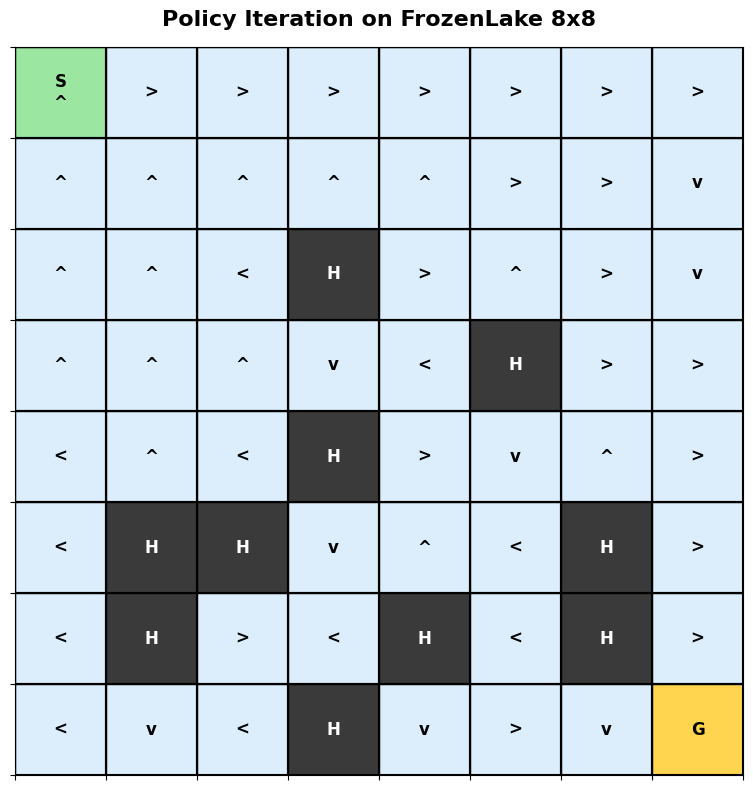

In [ ]:
def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
    desc = np.asarray(env.unwrapped.desc, dtype=str)
    policy_grid = np.asarray(policy).reshape(desc.shape)
    arrows = np.array(["<", "v", ">", "^"])
    colors = {
        "S": "#9be7a1",
        "F": "#dceefb",
        "H": "#3a3a3a",
        "G": "#ffd54f",
    }
    fig, ax = plt.subplots(figsize=(8, 8))
    for r in range(desc.shape[0]):
        for c in range(desc.shape[1]):
            tile = desc[r, c]
            rect = plt.Rectangle(
                (c, desc.shape[0] - 1 - r),
                1,
                1,
                facecolor=colors[tile],
                edgecolor="black",
                linewidth=1.5,
            )
            ax.add_patch(rect)
            if tile == "H":
                label = "H"
                color = "white"
            elif tile == "G":
                label = "G"
                color = "black"
            elif tile == "S":
                label = f"S\n{arrows[policy_grid[r, c]]}"
                color = "black"
            else:
                label = arrows[policy_grid[r, c]]
                color = "black"

            ax.text(
                c + 0.5,
                desc.shape[0] - 1 - r + 0.5,
                label,
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                color=color,
            )

    ax.set_xlim(0, desc.shape[1])
    ax.set_ylim(0, desc.shape[0])
    ax.set_xticks(np.arange(desc.shape[1] + 1))
    ax.set_yticks(np.arange(desc.shape[0] + 1))
    ax.grid(True, color="black", linewidth=1.0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=16, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()
policy, V = policy_iteration(P, nS, nA)
print("Value Function (V):\n", V.reshape(8, 8).round(3))
print("\nPolicy Grid:\n", policy.reshape(8, 8))
plot_policy_on_frozen_lake(
    env, policy, title="Policy Iteration on FrozenLake 8x8"
)